# Music Compatibility Between Two Spotify Users

**Goal:** given the audio profile of two users (their saved / top tracks), compute:
1. A music compatibility score (0-100%)
2. Which clusters each one listens to
3. 'Bridge' songs both might enjoy

Reuses the K-Means (k=2), PCA and StandardScaler from the main project. User profiles are
simulated from the existing dataset (preferred genres) and can be replaced with real
Spotify API data.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid", palette="Set2")
RANDOM_STATE = 42

In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "user_compatibility":
    PROJECT_ROOT = PROJECT_ROOT.parent

df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "spotify_tracks_clean.csv")
df = df.reset_index(drop=True)

print(f"Dataset: {df.shape[0]:,} tracks | {df['track_genre'].nunique()} genres")
print(f"Available genres: {sorted(df['track_genre'].unique())}")

Dataset: 89,741 tracks | 113 genres
Available genres: ['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient', 'anime', 'black-metal', 'bluegrass', 'blues', 'brazil', 'breakbeat', 'british', 'cantopop', 'chicago-house', 'children', 'chill', 'classical', 'club', 'comedy', 'country', 'dance', 'dancehall', 'death-metal', 'deep-house', 'detroit-techno', 'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm', 'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk', 'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove', 'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle', 'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian', 'indie', 'indie-pop', 'industrial', 'iranian', 'j-dance', 'j-idol', 'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino', 'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb', 'new-age', 'opera', 'pagode', 'party', 'piano', 'pop', 'pop-film', 'power-pop', 'progressive-house', 'psych-rock', 'punk'

## Audio Features

The same features as `06_clustering.ipynb` are used, to stay consistent with the trained K-Means.

In [3]:
CLUSTER_FEATURES = [
    "duration_min", "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo"
]

print("Features that define a user's audio profile:")
for f in CLUSTER_FEATURES:
    print(f"  - {f}")

Features that define a user's audio profile:
  - duration_min
  - danceability
  - energy
  - loudness
  - speechiness
  - acousticness
  - instrumentalness
  - liveness
  - valence
  - tempo


## Simulating User Profiles

In production, a profile would be built from the user's top tracks fetched from the Spotify API:
```
GET /me/top/tracks  ->  track IDs
GET /audio-features/{id}  ->  feature vector
profile = mean of the vectors of all tracks
```

Here we simulate two users with different genre preferences and sample real tracks from the dataset.

In [4]:
# User A: urban / energetic / danceable genres
CANDIDATE_A = ["hip-hop", "pop", "dance", "edm", "electronic", "disco",
               "funk", "r-n-b", "club", "party", "reggaeton", "dancehall"]

# User B: calm / acoustic / instrumental genres
CANDIDATE_B = ["acoustic", "classical", "ambient", "chill", "folk", "jazz",
               "new-age", "singer-songwriter", "piano", "study", "sleep"]

genres_a = [g for g in CANDIDATE_A if g in df["track_genre"].values]
genres_b = [g for g in CANDIDATE_B if g in df["track_genre"].values]

N = 50  # tracks per user (like a Spotify top-50)
df_a = df[df["track_genre"].isin(genres_a)].sample(n=N, random_state=RANDOM_STATE)
df_b = df[df["track_genre"].isin(genres_b)].sample(n=N, random_state=RANDOM_STATE + 1)

print(f"User A - Genres: {genres_a}")
print(f"\nSample tracks for User A:")
print(df_a[["track_name", "artists", "track_genre"]].head(5).to_string(index=False))

print(f"\nUser B - Genres: {genres_b}")
print(f"\nSample tracks for User B:")
print(df_b[["track_name", "artists", "track_genre"]].head(5).to_string(index=False))

User A - Genres: ['hip-hop', 'pop', 'dance', 'edm', 'electronic', 'disco', 'funk', 'r-n-b', 'club', 'party', 'reggaeton', 'dancehall']

Sample tracks for User A:
                                  track_name                                                        artists track_genre
                                 Miłego dnia                                                        Classic       disco
                     Coka 2.0 (From "Liger") Jaani;Lijo George-Dj Chetas;Sukh-E Muzical Doctorz;Lisa Mishra         pop
                              Champagne Talk                                                           King     hip-hop
                                       Fr Fr                                          Wiz Khalifa;Lil Skies       dance
Ihr könnt Euch einfach mal - Walter Wild Mix                    Ikke Hüftgold;Basti Trailerpark;Walter Wild       party

User B - Genres: ['acoustic', 'classical', 'ambient', 'chill', 'folk', 'jazz', 'new-age', 'singer-songwriter', 'piano

## Per-User Audio Profile

The profile is the **mean vector** of all audio features of the user's tracks - their
musical 'center of gravity'.

In [5]:
profile_a = df_a[CLUSTER_FEATURES].mean()
profile_b = df_b[CLUSTER_FEATURES].mean()

profiles = pd.DataFrame({
    "User A (Energetic)": profile_a,
    "User B (Acoustic)": profile_b
}).round(4)

display(profiles)

,User A (Energetic),User B (Acoustic)
duration_min,3.5416,3.8364
danceability,0.7026,0.4232
energy,0.6994,0.3264
loudness,-6.4249,-16.4937
speechiness,0.1090,0.0569
acousticness,0.2152,0.7086
instrumentalness,0.0502,0.5095
liveness,0.1748,0.1728
valence,0.5968,0.3208
tempo,116.5883,117.1946


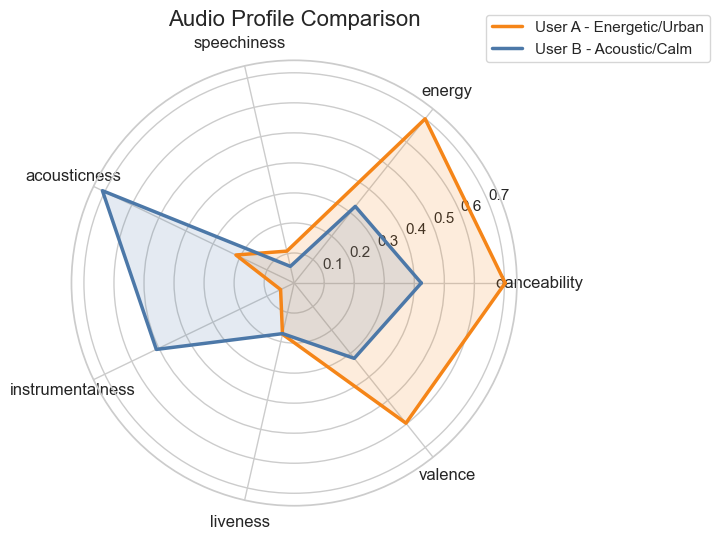

In [6]:
# Radar chart: visual comparison of profiles
radar_features = ["danceability", "energy", "speechiness", "acousticness",
                  "instrumentalness", "liveness", "valence"]

n = len(radar_features)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for col, color, label in [
    ("User A (Energetic)", "#F58518", "User A - Energetic/Urban"),
    ("User B (Acoustic)", "#4C78A8", "User B - Acoustic/Calm")
]:
    vals = profiles.loc[radar_features, col].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, color=color, linewidth=2.5, label=label)
    ax.fill(angles, vals, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, size=12)
ax.set_title("Audio Profile Comparison", size=16, pad=25)
ax.legend(loc="upper right", bbox_to_anchor=(1.45, 1.12))
plt.tight_layout()
plt.show()

## Clustering Analysis

The same k=2 K-Means from `notebook 06` is applied. It found two broad clusters:
- **Cluster 0**: Energetic / Danceable (high energy, high danceability, high valence)
- **Cluster 1**: Acoustic / Instrumental (high acousticness, high instrumentalness)

This shows which 'musical zone' each user lives in.

Cluster distribution - User A:
cluster
Energetic / Danceable      0.92
Acoustic / Instrumental    0.08
Name: proportion, dtype: float64

Cluster distribution - User B:
cluster
Acoustic / Instrumental    0.76
Energetic / Danceable      0.24
Name: proportion, dtype: float64


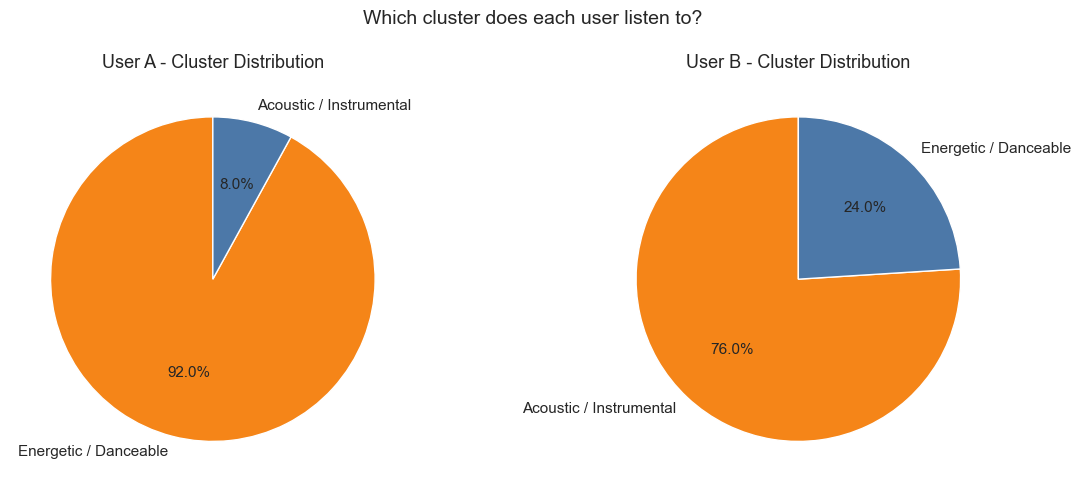

In [7]:
scaler = StandardScaler()
X_all = scaler.fit_transform(df[CLUSTER_FEATURES])

kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans.fit_predict(X_all)

CLUSTER_NAMES = {0: "Energetic / Danceable", 1: "Acoustic / Instrumental"}

dist_a = df.loc[df_a.index, "cluster"].value_counts(normalize=True).rename(CLUSTER_NAMES)
dist_b = df.loc[df_b.index, "cluster"].value_counts(normalize=True).rename(CLUSTER_NAMES)

print("Cluster distribution - User A:")
print(dist_a.round(3))
print("\nCluster distribution - User B:")
print(dist_b.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#F58518", "#4C78A8"]

for ax, (dist, title) in zip(axes, [(dist_a, "User A"), (dist_b, "User B")]):
    ax.pie(dist.values, labels=dist.index, autopct="%1.1f%%",
           colors=colors, startangle=90, textprops={"fontsize": 11})
    ax.set_title(f"{title} - Cluster Distribution", fontsize=13)

plt.suptitle("Which cluster does each user listen to?", fontsize=14)
plt.tight_layout()
plt.show()

## Music Compatibility Score

**Cosine similarity** measures the angle between the two profile vectors in feature space.
- 1.0 -> identical profiles
- 0.0 -> orthogonal (unrelated)
- -1.0 -> opposite profiles

It is normalized to [0, 1] to produce an interpretable compatibility score.

In [8]:
vec_a = scaler.transform(profile_a.values.reshape(1, -1))
vec_b = scaler.transform(profile_b.values.reshape(1, -1))

sim = cosine_similarity(vec_a, vec_b)[0][0]
compat = (sim + 1) / 2  # [-1, 1] -> [0, 1]

if compat >= 0.80:
    interp = "Very High - almost identical taste"
elif compat >= 0.65:
    interp = "High - significant compatibility"
elif compat >= 0.50:
    interp = "Moderate - common ground with notable differences"
elif compat >= 0.35:
    interp = "Low - different tastes with some overlap"
else:
    interp = "Very Low - nearly opposite musical preferences"

print(f"Cosine similarity:   {sim:.4f}")
print(f"Compatibility score: {compat:.1%}")
print(f"Interpretation:      {interp}")

Cosine similarity:   -0.7816
Compatibility score: 10.9%
Interpretation:      Very Low - nearly opposite musical preferences


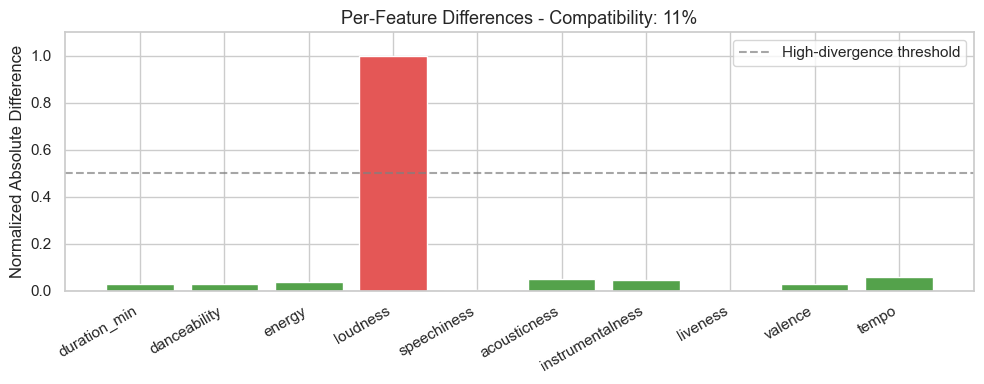

In [9]:
# Bar chart: which features separate them the most
diff = (profile_a - profile_b).abs()
diff_norm = diff / diff.max()

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ["#E45756" if v > 0.5 else "#54A24B" for v in diff_norm.values]
ax.bar(diff_norm.index, diff_norm.values, color=bar_colors)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.7, label="High-divergence threshold")
ax.set_title(f"Per-Feature Differences - Compatibility: {compat:.0%}", fontsize=13)
ax.set_ylabel("Normalized Absolute Difference")
ax.set_ylim(0, 1.1)
plt.xticks(rotation=30, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

## Bridge Recommendations

The **midpoint** of both profiles defines a 'hypothetical user' representing the shared
taste. The tracks closest to that point in feature space are the best candidates for a
**joint playlist**.

In [10]:
midpoint_raw = ((profile_a + profile_b) / 2).values.reshape(1, -1)
midpoint_scaled = scaler.transform(midpoint_raw)

dists = np.linalg.norm(X_all - midpoint_scaled, axis=1)
df["dist_midpoint"] = dists

bridge = (
    df.nsmallest(10, "dist_midpoint")[["track_name", "artists", "track_genre", "popularity", "cluster"]]
    .copy()
)
bridge["cluster"] = bridge["cluster"].map(CLUSTER_NAMES)
bridge["popularity"] = bridge["popularity"].astype(int)

print("Top 10 bridge tracks (closest to the midpoint of both profiles):")
display(bridge.reset_index(drop=True))

Top 10 bridge tracks (closest to the midpoint of both profiles):


,track_name,artists,track_genre,popularity,cluster
0,Light Of Day,Anna Ternheim,swedish,0,Energetic / Danceable
1,Let ‘Em In,John Pizzarelli,guitar,22,Energetic / Danceable
2,Smoothie Song,Nickel Creek,bluegrass,21,Acoustic / Instrumental
3,Rehnuma,Last Minute India,indian,44,Acoustic / Instrumental
4,散步之年,my little airport,cantopop,29,Acoustic / Instrumental
5,Just A Closer Walk,Steve Ivey,bluegrass,13,Energetic / Danceable
6,Give a Shit,Greensky Bluegrass,bluegrass,24,Energetic / Danceable
7,Painting Silhouettes,Quantic,trip-hop,57,Acoustic / Instrumental
8,All Apologies,Nirvana,grunge,60,Energetic / Danceable
9,Harry Houdini,Tomas Andersson Wij,swedish,35,Acoustic / Instrumental


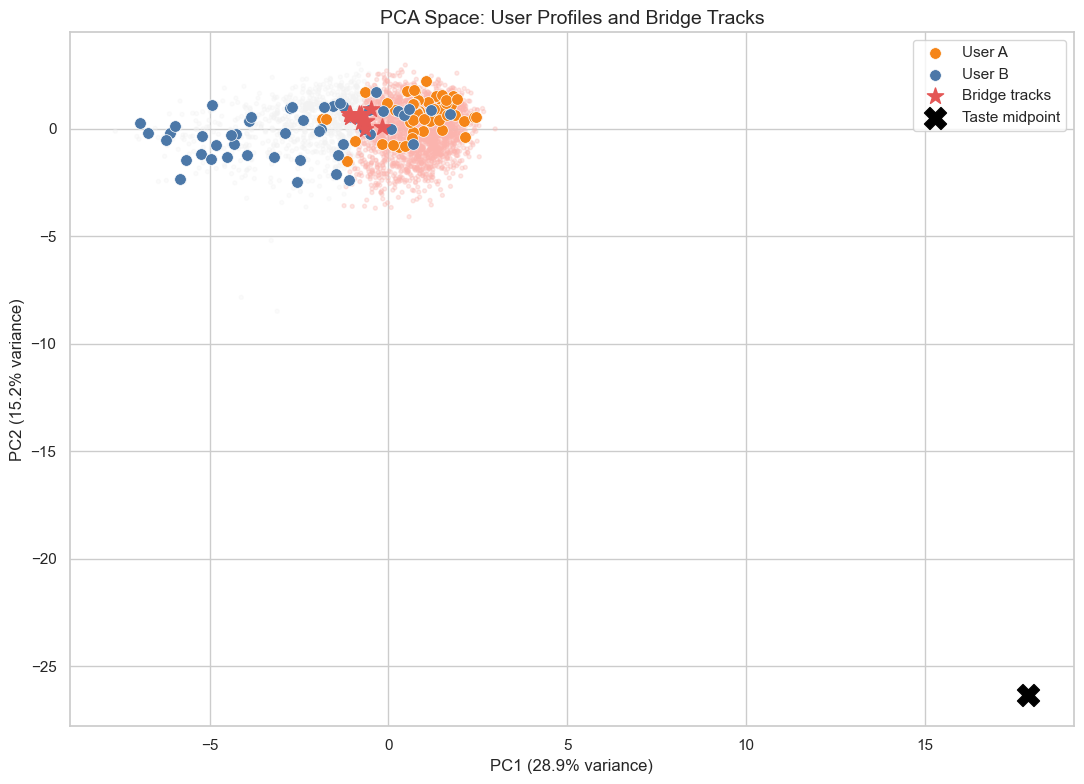

In [11]:
# PCA view: position of the users and the bridge tracks
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_all)

rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(df), size=3000, replace=False)
bridge_idx = df.nsmallest(10, "dist_midpoint").index.values

fig, ax = plt.subplots(figsize=(11, 8))

# Background: dataset sample colored by cluster
ax.scatter(coords[sample_idx, 0], coords[sample_idx, 1],
           c=df.loc[sample_idx, "cluster"], cmap="Pastel1",
           alpha=0.3, s=8, label="_")

# Each user's tracks
ax.scatter(coords[df_a.index, 0], coords[df_a.index, 1],
           c="#F58518", s=70, label="User A", zorder=3,
           edgecolors="white", linewidths=0.5)
ax.scatter(coords[df_b.index, 0], coords[df_b.index, 1],
           c="#4C78A8", s=70, label="User B", zorder=3,
           edgecolors="white", linewidths=0.5)

# Bridge tracks
ax.scatter(coords[bridge_idx, 0], coords[bridge_idx, 1],
           c="#E45756", s=150, marker="*", label="Bridge tracks", zorder=4)

# Midpoint
midpoint_2d = pca.transform(midpoint_raw)
ax.scatter(midpoint_2d[0, 0], midpoint_2d[0, 1],
           c="black", s=250, marker="X", label="Taste midpoint", zorder=5)

ax.set_title("PCA Space: User Profiles and Bridge Tracks", fontsize=14)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Integrating the Real Spotify API

The block below shows how to fetch real user profiles with the `spotipy` library. It is
commented out because it requires credentials from a Spotify Developer App.

Once `profile_a` and `profile_b` are obtained from the API, the rest of the analysis is
identical.

In [12]:
# Available endpoints and their role in this analysis
api_info = {
    "Endpoint": [
        "GET /me/top/tracks",
        "GET /me/tracks",
        "GET /me/player/recently-played",
        "GET /audio-features/{id}",
        "GET /me/top/artists",
        "GET /recommendations"
    ],
    "Data returned": [
        "Top 50 tracks (short / medium / long term)",
        "Saved (liked) songs",
        "Last 50 played tracks",
        "danceability, energy, loudness, acousticness, etc.",
        "Top artists + associated genres",
        "Tracks recommended from song/genre seeds"
    ],
    "Use in the model": [
        "Build the user's audio profile",
        "Enrich the profile with more tracks",
        "Capture recent preferences",
        "Get each track's feature vector",
        "Infer preferred genres",
        "Use bridge tracks as seeds for more recommendations"
    ]
}
display(pd.DataFrame(api_info))

,Endpoint,Data returned,Use in the model
0,GET /me/top/tracks,Top 50 tracks (short / medium / long term),Build the user's audio profile
1,GET /me/tracks,Saved (liked) songs,Enrich the profile with more tracks
2,GET /me/player/recently-played,Last 50 played tracks,Capture recent preferences
3,GET /audio-features/{id},"danceability, energy, loudness, acousticness, ...",Get each track's feature vector
4,GET /me/top/artists,Top artists + associated genres,Infer preferred genres
5,GET /recommendations,Tracks recommended from song/genre seeds,Use bridge tracks as seeds for more recommenda...


In [13]:
# ---------- ILLUSTRATIVE CODE - requires Spotify credentials ----------
#
# pip install spotipy
#
# import spotipy
# from spotipy.oauth2 import SpotifyOAuth
#
# sp = spotipy.Spotify(auth_manager=SpotifyOAuth(
#     client_id="YOUR_CLIENT_ID",
#     client_secret="YOUR_CLIENT_SECRET",
#     redirect_uri="http://localhost:8888/callback",
#     scope="user-top-read user-library-read user-read-recently-played"
# ))
#
# def get_user_audio_profile(sp_client, limit=50, time_range="medium_term"):
#     """Return the user's mean audio-feature vector."""
#     top = sp_client.current_user_top_tracks(limit=limit, time_range=time_range)
#     ids = [t["id"] for t in top["items"]]
#     features = sp_client.audio_features(ids)
#     feat_df = pd.DataFrame([f for f in features if f is not None])
#     # duration_min is not returned by the API - derive it from duration_ms
#     feat_df["duration_min"] = feat_df["duration_ms"] / 60000
#     return feat_df[CLUSTER_FEATURES].mean()
#
# # Replace the simulation lines with:
# # profile_a = get_user_audio_profile(sp_user_a)
# # profile_b = get_user_audio_profile(sp_user_b)

print("Illustrative code - see the comments above for real API integration.")

Illustrative code - see the comments above for real API integration.


## Conclusions

### What this analysis produces
| Output | Description |
|--------|-------------|
| Compatibility score | Normalized cosine similarity between audio profiles |
| Cluster distribution | % of tracks in each musical zone (energetic vs acoustic) |
| Radar chart | Visual feature-by-feature comparison |
| Divergence bar chart | Which dimensions separate them the most |
| Top 10 bridge tracks | Candidates for a joint playlist |
| PCA view | Spatial position of both users and the bridge tracks |

### How to extend
- **N users**: compute the cross compatibility matrix and show it as a heatmap.
- **Dynamic playlist**: generate N bridge tracks and use them as seeds in `GET /recommendations`.
- **Compatibility over time**: recompute with `recently_played` periodically and see whether tastes converge.
- **Popularity classification**: pass the bridge tracks through the notebook 05 classifier to predict whether they will be popular for both users.

### Reused project models
| Notebook | Technique | Use here |
|----------|-----------|----------|
| `06_clustering.ipynb` | K-Means k=2 | Classify each user's musical zone |
| `04_pca.ipynb` | 2D PCA | Visualize profiles in reduced space |
| `02_cleaning_feature_engineering.ipynb` | StandardScaler | Scale before clustering and similarity |